In [ ]:
from google.colab import files
uploaded = files.upload()

Saving car_prediction_data.csv to car_prediction_data (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv("car_prediction_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("car_prediction_data.csv")

# View first rows
print(df.head())

# Dataset info
print(df.info())

# Descriptive statistics
print(df.describe())

# Missing values
print(df.isnull().sum())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non

DATA VISUALIZATION

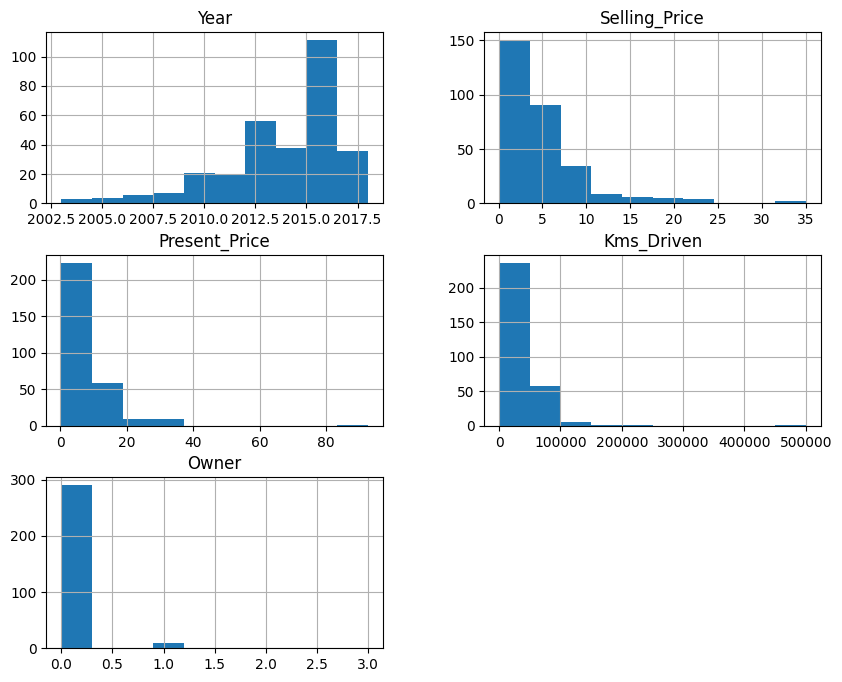

In [ ]:
#Histogram
df.hist(figsize=(10,8))
plt.show()

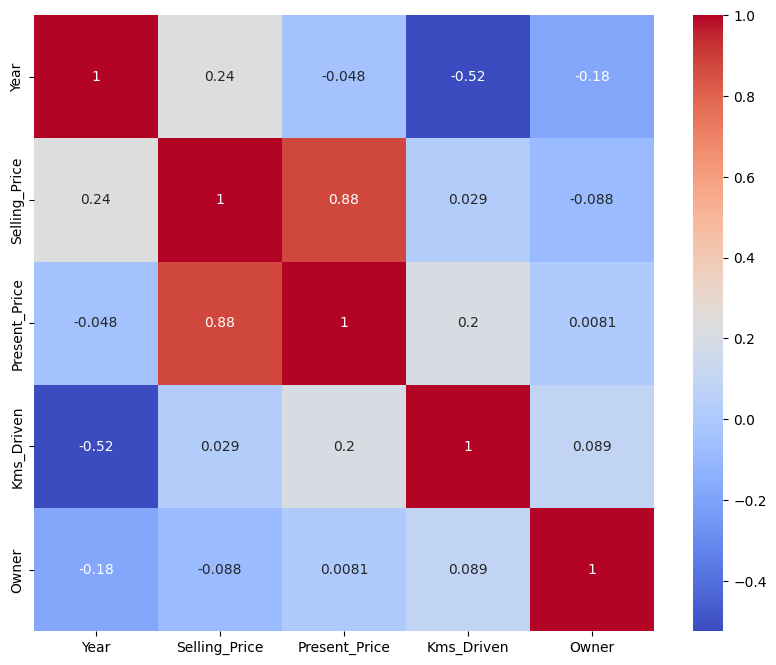

In [ ]:
import numpy as np
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

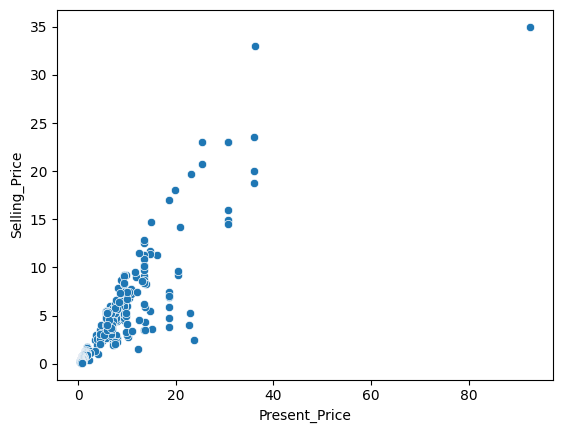

In [ ]:
#scatter plot
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.show()

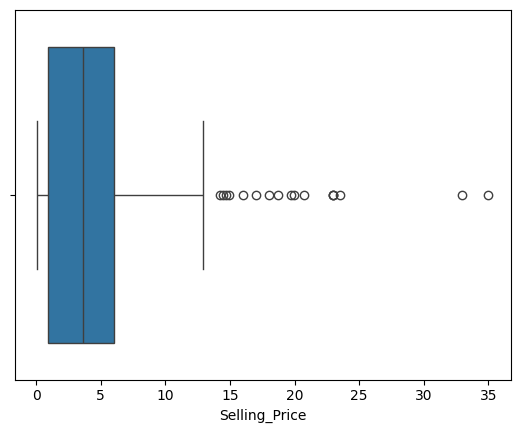

In [ ]:
#Box plot
sns.boxplot(x=df['Selling_Price'])
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask_numeric = ((numeric_df < lower_bound) | (numeric_df > upper_bound)).any(axis=1)
df_clean = df[~outlier_mask_numeric]

Price Categorization


In [ ]:
def price_category(price):
    if price < 3:
        return "Low"
    elif price < 7:
        return "Medium"
    else:
        return "High"

df_clean.loc[:, 'Price_Category'] = df_clean['Selling_Price'].apply(price_category)
display(df_clean.head())

/tmp/ipykernel_911/413384796.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.loc[:, 'Price_Category'] = df_clean['Selling_Price'].apply(price_category)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Price_Category
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,Medium
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,Medium
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,High
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,Low
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,Medium


Defining X and Y

In [ ]:
X = df_clean.drop(['Selling_Price', 'Price_Category'], axis=1)
y = df_clean['Price_Category']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,6.87,42450,Diesel,Dealer,Manual,0



Target (y) head:


,Price_Category
0,Medium
1,Medium
2,High
3,Low
4,Medium


Encoding to numerical forms


In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded Features (X) head:")
display(X.head())

Encoded Features (X) head:


,Year,Present_Price,Kms_Driven,Owner,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,Car_Name_Bajaj Avenger 220,Car_Name_Bajaj Avenger 220 dtsi,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,2013,9.54,43000,0,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,2017,9.85,6900,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2011,4.15,5200,0,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,2014,6.87,42450,0,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


Trai test split


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (184, 96)
X_test shape: (80, 96)
y_train shape: (184,)
y_test shape: (80,)


Training


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Scale numerical features for models sensitive to feature scaling (like Logistic Regression and ANN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "ANN (MLPClassifier)": MLPClassifier(max_iter=1000, random_state=42)
}

for name, model in models.items():
    print(f"Training {name}...")
    if name == "Logistic Regression" or name == "ANN (MLPClassifier)":
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    print(f"{name} trained.")

Training Logistic Regression...
Logistic Regression trained.
Training Decision Tree Classifier...
Decision Tree Classifier trained.
Training Random Forest Classifier...
Random Forest Classifier trained.
Training ANN (MLPClassifier)...
ANN (MLPClassifier) trained.


## 6. Evaluate Each Model



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
predictions = {}

for name, model in models.items():
    if name == "Logistic Regression" or name == "ANN (MLPClassifier)":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    predictions[name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

Result


In [ ]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest Classifier,0.8875,0.899653,0.8875,0.889366
1,Decision Tree Classifier,0.8625,0.876563,0.8625,0.866647
0,Logistic Regression,0.8375,0.855943,0.8375,0.839947
3,ANN (MLPClassifier),0.7000,0.783929,0.7000,0.692083


Confusion matrix


Best performing model: Random Forest Classifier


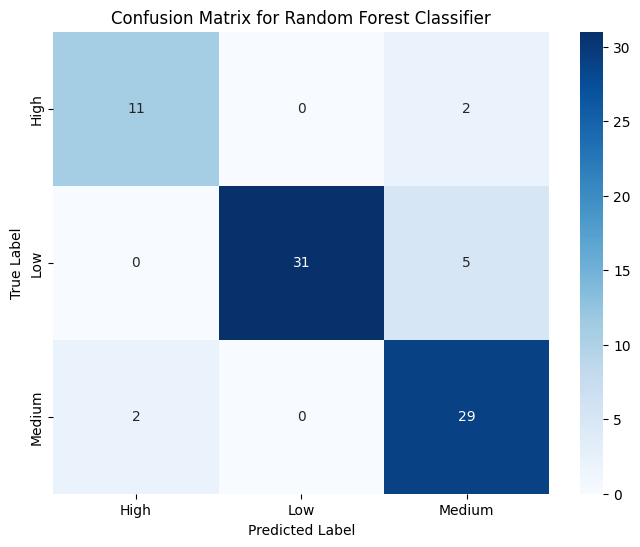

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best performing model based on F1-Score
best_model_name = results_df.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]
best_y_pred = predictions[best_model_name]

print(f"Best performing model: {best_model_name}")

# Generate confusion matrix
cm = confusion_matrix(y_test, best_y_pred, labels=best_model.classes_)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

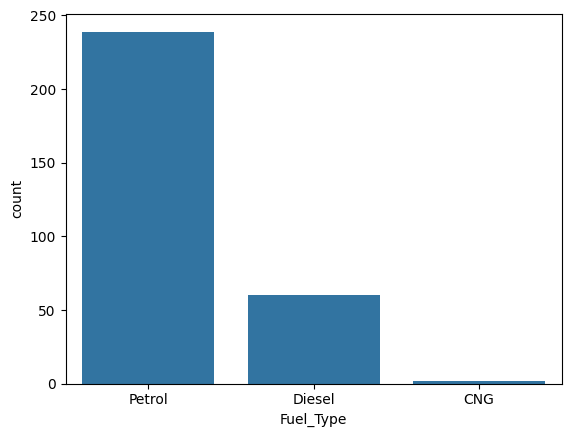

In [ ]:
#countplot
sns.countplot(x='Fuel_Type', data=df)
plt.show()

DESCRIPTIVE STATISTICS


In [ ]:
numeric_df = df.select_dtypes(include=['number'])
print("Mean:\n", numeric_df.mean())
print("\nMedian:\n", numeric_df.median())
print("\nStandard Deviation:\n", numeric_df.std())
print("\nMinimum:\n", numeric_df.min())
print("\nMaximum:\n", numeric_df.max())

Mean:
 Year              2013.627907
Selling_Price        4.661296
Present_Price        7.628472
Kms_Driven       36947.205980
Owner                0.043189
dtype: float64

Median:
 Year              2014.0
Selling_Price        3.6
Present_Price        6.4
Kms_Driven       32000.0
Owner                0.0
dtype: float64

Standard Deviation:
 Year                 2.891554
Selling_Price        5.082812
Present_Price        8.644115
Kms_Driven       38886.883882
Owner                0.247915
dtype: float64

Minimum:
 Year             2003.00
Selling_Price       0.10
Present_Price       0.32
Kms_Driven        500.00
Owner               0.00
dtype: float64

Maximum:
 Year               2018.0
Selling_Price        35.0
Present_Price        92.6
Kms_Driven       500000.0
Owner                 3.0
dtype: float64


In [ ]:
print(results_df)

                      Model  Accuracy  Precision  Recall  F1-Score
0       Logistic Regression    0.8375   0.855943  0.8375  0.839947
1  Decision Tree Classifier    0.8625   0.876563  0.8625  0.866647
2  Random Forest Classifier    0.8875   0.899653  0.8875  0.889366
3       ANN (MLPClassifier)    0.7000   0.783929  0.7000  0.692083


In [ ]:
classes = sorted(y.unique())

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

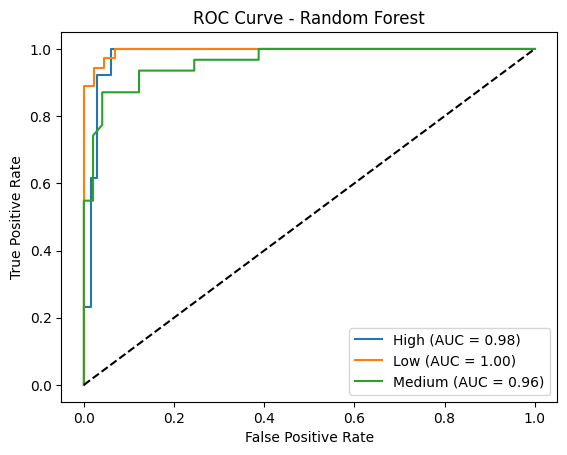

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob = rf.predict_proba(X_test)

# Convert labels to binary
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# Plot ROC
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

In [ ]:
print(results_df)

                      Model  Accuracy  Precision  Recall  F1-Score
0       Logistic Regression    0.8375   0.855943  0.8375  0.839947
1  Decision Tree Classifier    0.8625   0.876563  0.8625  0.866647
2  Random Forest Classifier    0.8875   0.899653  0.8875  0.889366
3       ANN (MLPClassifier)    0.7000   0.783929  0.7000  0.692083
